## Imports

Use ```pip install factor-analyzer``` to install the factor_analyzer package. This package is used to perform factor analysis with the ULS method, which is not implemented in sklearn. At the time of writing, the latest version of factor_analyzer is 0.5.1.

In [39]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#version for factor_analyser: 0.5.1
from factor_analyzer import FactorAnalyzer
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.options.display.max_columns = 70

In [ ]:
data_raw = pd.read_csv('./IPIP-FFM-data-8Nov2018/data-final.csv', sep='\t')

#Select columns to only keep the 50 items that measure the 5 personality traits. 
#See codebook.txt for more details on all the columns.
data = data_raw.iloc[:, :50]

#We remove all lines where IPC is not 1, as these could be multiple submissions of the same person.
#The total number of lines in the original dataset is 1 015 341, and 696 845 after cleaning.
print("Number lines removed to avoid multiple submission : ", np.sum(data_raw.IPC != 1))
data = data[data_raw.IPC == 1]

#We remove lines where data is missing
n_before = len(data)
data = data.dropna()
n_after = len(data)
print("Number lines removed to avoid missing data : ", n_before - n_after)

#NE GARDE QUE LE 100 000 PREMIERS LIGNES POUR ACCELERER LES CALCULS (A enlever pour l'analyse finale)
data = data.iloc[:100000, :]

data

Number lines removed to avoid multiple submission :  318496
Number lines removed to avoid missing data :  1141


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,1.0,2.0,1.0,4.0,2.0,5.0,3.0,4.0,4.0
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,2.0,2.0,3.0,1.0,4.0,4.0,2.0,5.0,2.0,3.0,1.0,4.0,4.0,3.0,3.0
5,3.0,3.0,4.0,2.0,4.0,2.0,2.0,3.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,3.0,1.0,4.0,2.0,3.0,2.0,3.0,4.0,4.0,3.0,2.0,4.0,1.0,3.0,2.0,4.0,3.0,4.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,4.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426024,1.0,5.0,2.0,4.0,2.0,4.0,1.0,5.0,1.0,5.0,3.0,3.0,4.0,3.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,5.0,4.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,2.0,4.0,1.0,4.0,3.0,3.0,2.0,2.0,4.0,1.0,2.0,4.0,3.0,2.0,4.0,2.0,2.0,3.0
426025,2.0,3.0,5.0,3.0,4.0,3.0,3.0,1.0,2.0,3.0,4.0,5.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,5.0,3.0,2.0,5.0,3.0,5.0,2.0,3.0,5.0,3.0,5.0,4.0,5.0,1.0,5.0,4.0,4.0,5.0,5.0,5.0,4.0,1.0,3.0,1.0,3.0,3.0,5.0,2.0,3.0,3.0
426026,3.0,1.0,4.0,3.0,4.0,2.0,4.0,4.0,3.0,2.0,2.0,2.0,4.0,3.0,3.0,4.0,4.0,3.0,4.0,2.0,4.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,4.0,4.0,4.0,3.0,5.0,4.0,4.0,4.0,4.0,2.0,4.0,4.0,5.0,2.0,5.0,2.0,4.0,2.0,4.0,4.0,4.0,4.0
426027,4.0,2.0,4.0,3.0,4.0,2.0,4.0,3.0,3.0,2.0,3.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,4.0,4.0,3.0,2.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,2.0,4.0,2.0,4.0,1.0,4.0,3.0,4.0,4.0


## Factor analysis

We perform factor analysis on the data to reduce the dimensionnality of the data. In pychological terms, it means that to find the underlying fundamental personality traits that (partially) explain the responses to the questions.

### Note on rotation and interfactorial correlations

We apply factor analysis to the data, to extract the Big Five personality traits, with varimax rotation to make the traits more interpretable.

We could have used non orthogonal rotation methods, like oblimin which allow for correlated factors. It is commonly recommended to use oblique rotation in psychometric analysis, as said in Fabrigar et al. (https://doi.org/10.1037/1082-989X.4.3.272): 
>*For many constructs examined in psychology (e.g., mental abilities, personality traits, attitudes), there is substantial theoretical and empirical basis for expecting these constructs (or dimensions of these constructs) to be correlated with one another. Therefore, oblique rotations provide a more accurate and realistic representation of how constructs are likely to be related to one another.*

However, our goal here is not to explain the correlations between factors, but to perform clustering on the factors, and we fear that oblique rotation will deform the space in way that will influence the clustering. [MAYBE NOT FOR FULL MATRIX GMM, TO CHECK]
Additionally, Costello et Osborne (https://doi.org/10.1037/1082-989X.4.3.272) suggest that orthogonal and oblique rotation often produce similar results so we will not loose much interpretability by using varimax rotation.

### Note on the factor analysis extraction method

FactorAnalyser from factor_analyser use ULS method (or minres, or iterated principal factor method) to perform factor analysis, which does not assume that factors are normally distributed, contrarily to the maximum likelihood method. 
And since the assumption that factor follows Gaussian distribution directly contradicts the assumption of the Gaussian mixture model that we will use later, we think that it is preferable to use the ULS method. However, this don't seem to bother Gerlach, M., Farb, B., Revelle, W. et al. (https://doi.org/10.1038/s41562-018-0419-z), who use the ML method before using GMM. For the sake of comparison, we also perform factor analysis with the ML method in the appendix of this notebook, and the results are very similar to the ones given by the ULS method. This suggest that the choice of the extraction method does not have a strong influence on the results.

**Possible bug**: FactorAnalyzer use sklearn.utils.check_array's old parameter 'force_all_finite' which have been renamed to 'ensure_all_finite' in sklearn 1.6. 

You can either modify the source code of factor_analyzer in factor_analyser.py (locate this file with the error message then replace each occurrence of 'force_all_finite' by 'ensure_all_finite') or downgrade sklearn to 1.6.

In [ ]:
data_np = data.to_numpy()
#The ULS method have several names: minres, iterated principal factor method or unweighted least squares method.
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='minres', svd_method='lapack') 

#We create a new dataframe with the 5 personality traits as columns, and the same index as the original data.
data_fa = pd.DataFrame(fa.fit_transform(data_np))
data_fa

,0,1,2,3,4
0,1.636997,-0.770522,-0.067596,-0.237108,0.769483
1,-1.216507,-0.867331,1.153918,0.404740,-0.681859
2,-0.711203,-0.889287,0.694177,0.042006,0.025220
3,-0.282629,-0.428204,0.130661,-1.252437,0.055212
4,-0.016675,-1.218435,0.088890,0.252716,0.194785
...,...,...,...,...,...
299995,-1.400049,-0.675708,-0.122383,-1.225390,-0.899952
299996,0.319815,0.306218,0.140429,1.052774,-0.394749
299997,0.878432,0.533468,-0.098068,0.471663,0.440889
299998,0.840284,-0.052484,0.111441,0.535208,-0.078281


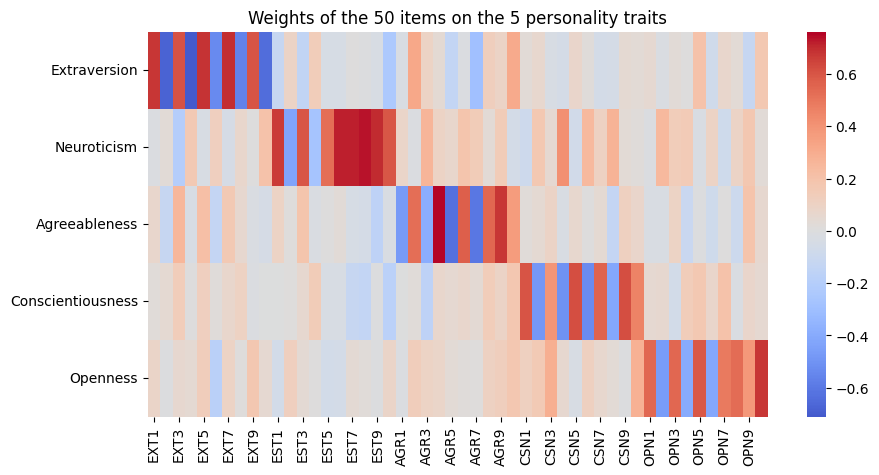

In [42]:
#plot the weights of the 50 items on the 5 personality traits as a heatmap
weights = pd.DataFrame(fa.loadings_.T, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness']) #FactorAnalyzer's loading transposed is equivalent to sklearn's components_.

plt.figure(figsize=(10, 5))
sns.heatmap(weights, cmap='coolwarm', center=0)
plt.title('Weights of the 50 items on the 5 personality traits')
plt.show()

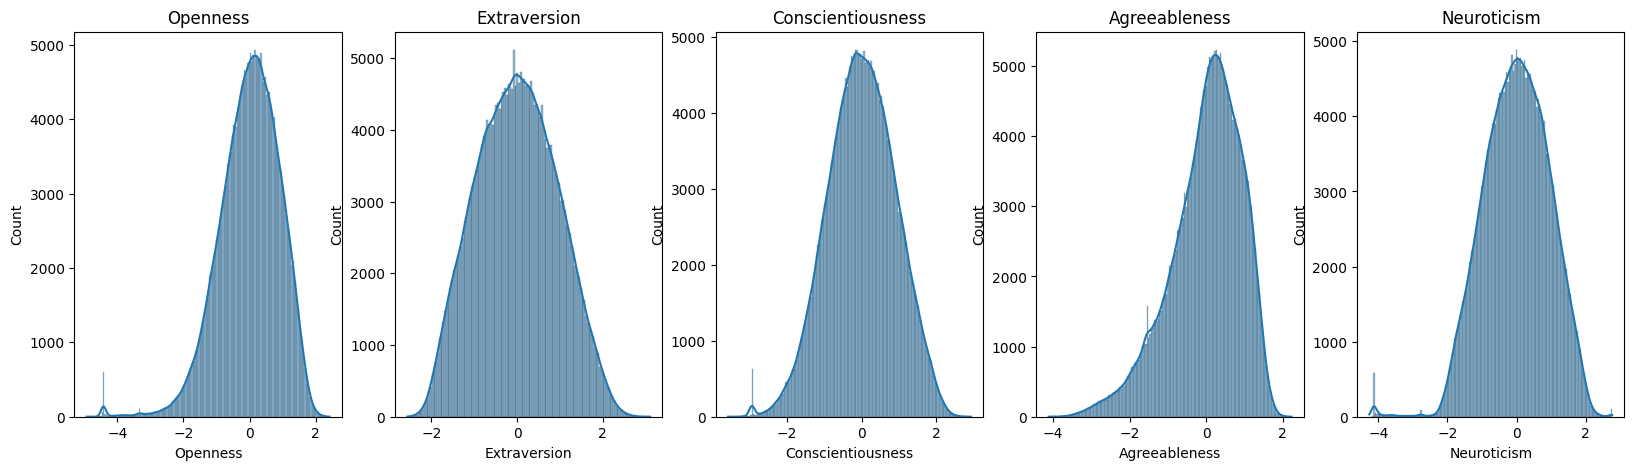

In [ ]:
#From the previous plot, we can infer that factors are ordered as follow:
data_fa.columns = ['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness']
#plot the distribution of the 5 personality traits in 5 subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
sns.histplot(data_fa['Openness'], ax=axs[0], kde=True)
sns.histplot(data_fa['Conscientiousness'], ax=axs[2], kde=True)
sns.histplot(data_fa['Extraversion'], ax=axs[1], kde=True)
sns.histplot(data_fa['Agreeableness'], ax=axs[3], kde=True)
sns.histplot(data_fa['Neuroticism'], ax=axs[4], kde=True)
axs[0].set_title('Openness')
axs[2].set_title('Conscientiousness')
axs[1].set_title('Extraversion')
axs[3].set_title('Agreeableness')
axs[4].set_title('Neuroticism')
plt.show()

## APPENDIX: Comparison of the results provided by ULS vs ML extraction methods for factor analysis

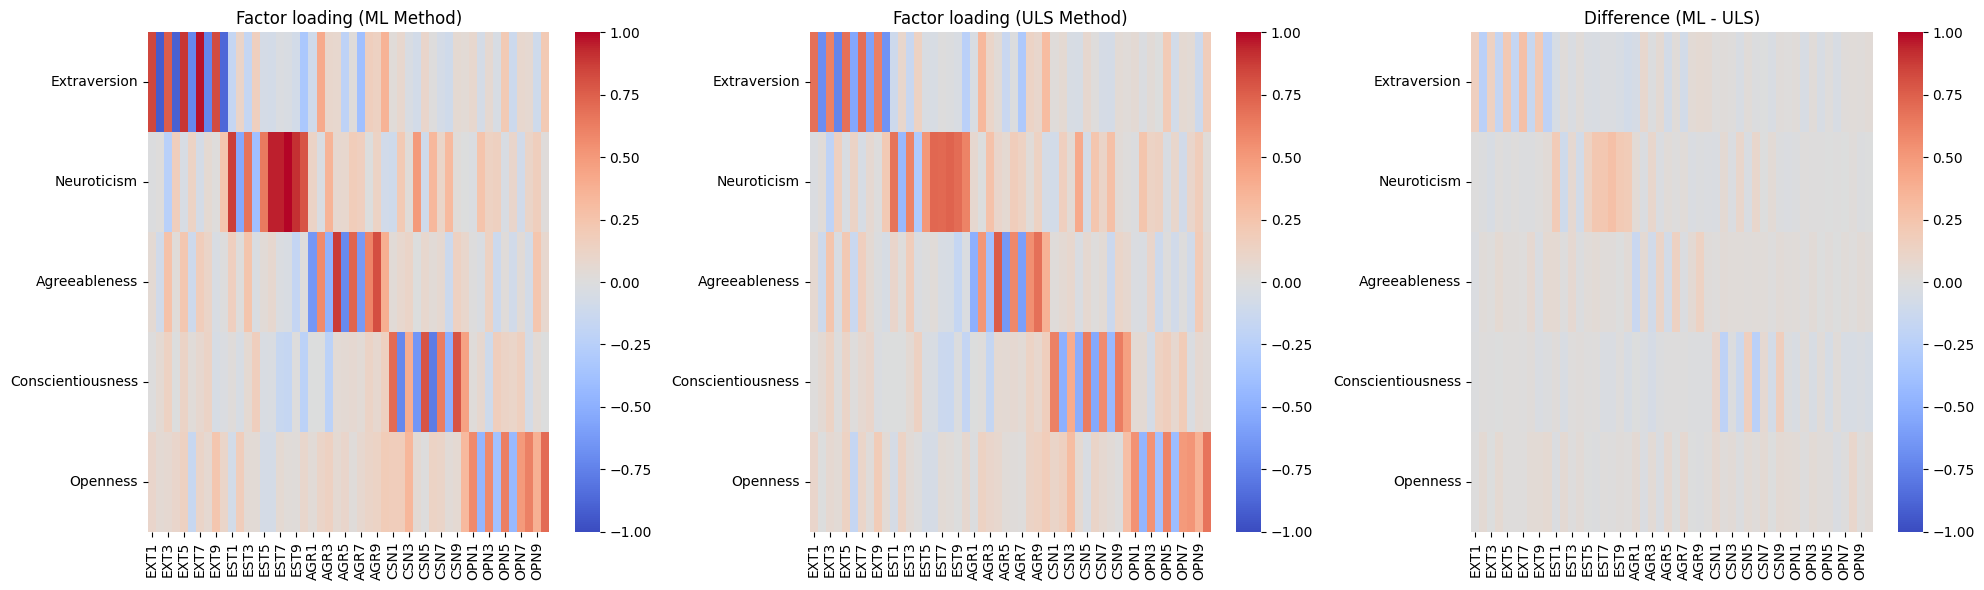

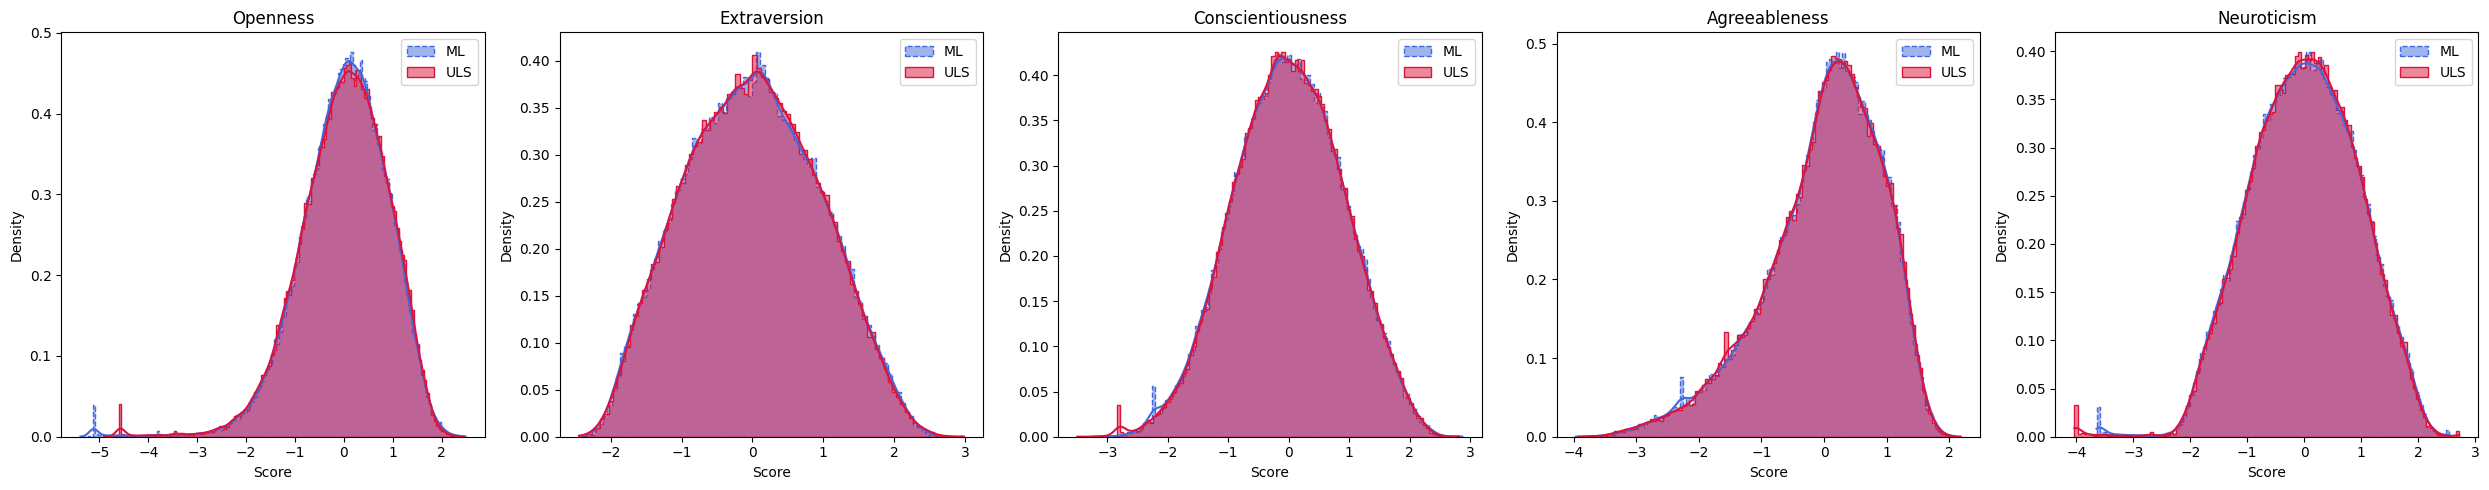

In [ ]:
#Perform factor analysis with the maximum likelihood method, for comparison with the ULS method.
fa_ml = FactorAnalysis(n_components=5, rotation='varimax', svd_method='lapack') #sklearn's FactorAnalysis use the maximum likelihood method to perform factor analysis, which assume that factors are normally distributed, contrarily to the ULS method used by FactorAnalyzer.
data_fa_ml = pd.DataFrame(fa_ml.fit_transform(data_np))

#Technical manipulations to make results of the ML method comparable to the ULS method:
#From our (not shown) observations, factor are ordered as follows:
data_fa_ml.columns = ['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness']
weights_ml = pd.DataFrame(fa_ml.components_, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness'])
#Reorder the rows of the weights dataframe to match the order of the factors given by the ULS method, for better comparison.
weights_ml = weights_ml.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'])
data_fa_ml = data_fa_ml.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'], axis=1)
#Invert axes to match the order of the factors given by the ULS method, for better comparison.
weights_ml = -weights_ml
data_fa_ml = -data_fa_ml
weights_ml.loc['Neuroticism'] = -weights_ml.loc['Neuroticism']
data_fa_ml['Neuroticism'] = -data_fa_ml['Neuroticism']

#Loading matrix plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
heatmap_kwargs = {
    'cmap': 'coolwarm',
    'center': 0,
    'vmin': -1,
    'vmax': 1,
    'cbar': True
}
sns.heatmap(weights_ml, ax=ax1, **heatmap_kwargs)
ax1.set_title('Factor loading (ML Method)')
sns.heatmap(weights, ax=ax2, **heatmap_kwargs)
ax2.set_title('Factor loading (ULS Method)')
sns.heatmap(weights_ml - weights, ax=ax3, **heatmap_kwargs)
ax3.set_title('Difference (ML - ULS)')
plt.tight_layout()
plt.show()

#Histogram plots
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
traits = ['Openness', 'Extraversion', 'Conscientiousness', 'Agreeableness', 'Neuroticism']
for i, trait in enumerate(traits):
    sns.histplot(data_fa_ml[trait], ax=axs[i], kde=True, 
                 color='royalblue', label='ML', alpha=0.5, stat="density", element="step", linestyle='dashed')
    sns.histplot(data_fa[trait], ax=axs[i], kde=True, 
                 color='crimson', label='ULS', alpha=0.5, stat="density", element="step")
    axs[i].set_title(trait)
    axs[i].set_xlabel('Score')
    axs[i].legend() 
plt.tight_layout()
plt.show()

We can see that the loadings and distributions of the factor with ULS method are very similar to the ones given by the factor analysis with ML method, which suggest that the choice of the extraction method does not have a strong influence on the results. However, we think that it is preferable to use the ULS method, since it does not assume that factors are normally distributed, which is more consistent with the assumptions of the gaussian mixture model that we will use later.